In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
# Load the data
df=pd.read_csv("car_price_dataset.csv")

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   object 
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   object 
 5   Transmission  2000 non-null   object 
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), object(3)
memory usage: 172.0+ KB
None


In [ ]:
df.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [ ]:
df_cleaned=df.drop(columns=["Car_ID"])
df_cleaned.head()

,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [ ]:
df_final=pd.get_dummies(df_cleaned,drop_first=True)
df_final.head()

,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Tesla,Brand_Toyota,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Manual
0,2023,1.2,180635,4,3,82,34309.25,True,False,False,False,False,False,True,False,True
1,2018,3.2,35628,2,4,259,55153.60,False,False,True,False,False,True,False,False,True
2,2008,2.2,74672,3,2,333,41894.40,False,False,False,False,False,False,False,False,True
3,2017,2.2,51246,4,4,381,54046.70,False,False,True,False,False,False,False,True,False
4,2012,2.4,147233,3,4,290,38010.35,False,False,True,False,False,True,False,False,True


In [ ]:
from sklearn.model_selection import   train_test_split
X=df_final.drop("Price",axis=1)
y=df_final["Price"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error
predictions=model.predict(X_test)
mae=mean_absolute_error(y_test,predictions)
print("Mean Absolute Error:",mae)

Mean Absolute Error: 2108.730089999998


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Calculate Mean Squared Error
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse:.2f}")

# 2. Calculate Root Mean Squared Error (RMSE)
# We take the square root to bring the value back to the unit of "Dollars"
rmse = np.sqrt(mse)
print(f"On average (penalizing big errors), our predictions are off by: ${rmse:.2f}")

Mean Squared Error: 6806216.91
On average (penalizing big errors), our predictions are off by: $2608.87


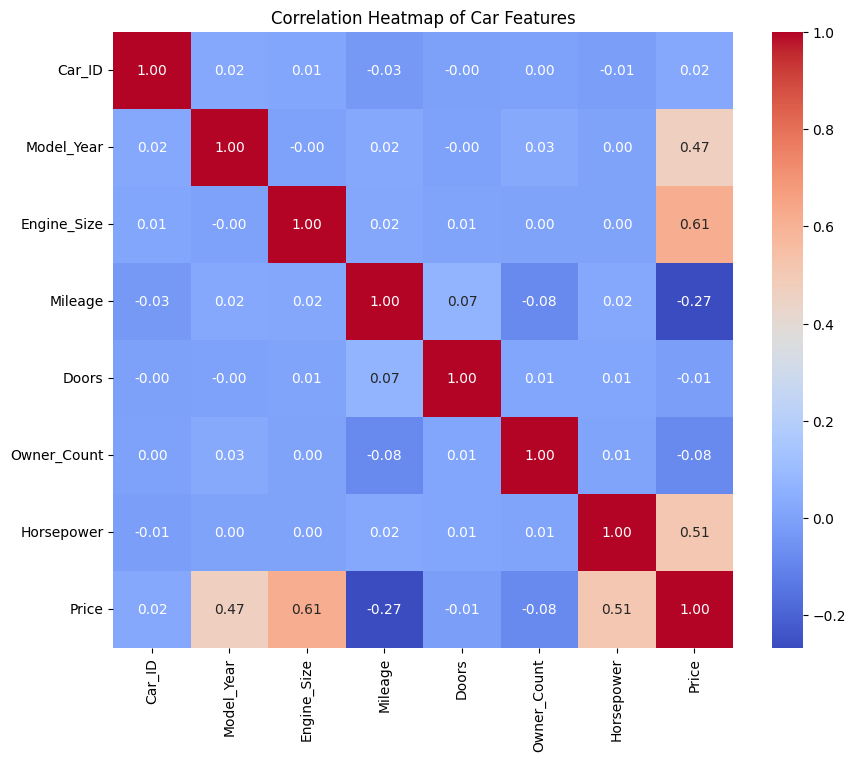

In [ ]:
numeric_df=df.select_dtypes(include=['float64','int64'])
corr_matrix=numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title('Correlation Heatmap of Car Features')
plt.show()

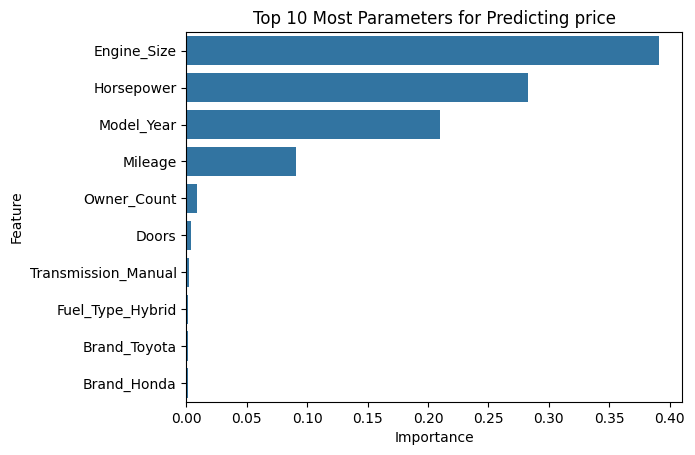

In [ ]:
# Get important levels from the model
importance=model.feature_importances_
feature_names=X.columns
#Create a small table for the top 5
feature_importance_df=pd.DataFrame({'Feature':feature_names,'Importance':importance})
feature_importance_df=feature_importance_df.sort_values(by='Importance',ascending=False)
# Visualize it
sns.barplot(x='Importance',y='Feature',data=feature_importance_df.head(10))
plt.title('Top 10 Most Parameters for Predicting price')
plt.show()

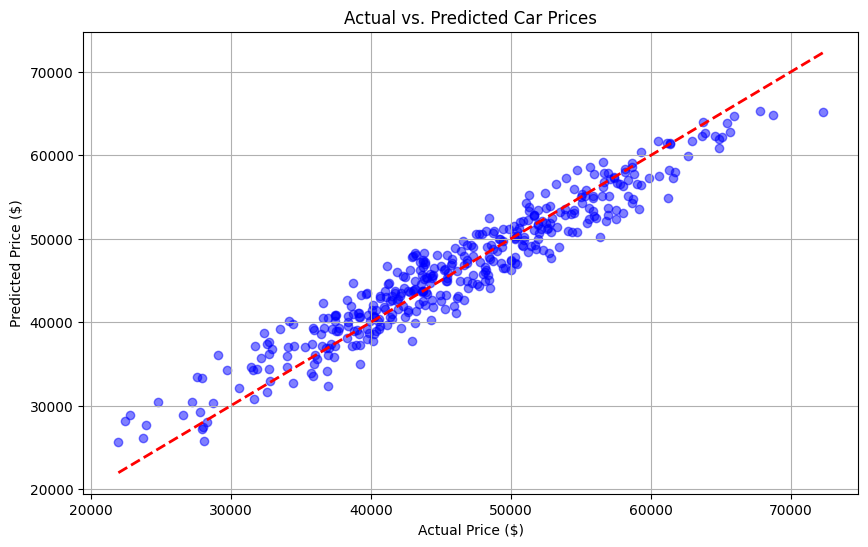

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Use the model to get predictions for the test set
predictions = model.predict(X_test)

# 2. Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='blue')

# 3. Add the 'Perfect Prediction' line
# This line shows where the points would be if the model was 100% accurate
ideal_line = [y_test.min(), y_test.max()]
plt.plot(ideal_line, ideal_line, color='red', lw=2, linestyle='--')

# 4. Labels and Title
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs. Predicted Car Prices')
plt.grid(True)
plt.show()